<a href="https://colab.research.google.com/github/ahdanaufi/Tugas/blob/main/ETS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dataset: AI4I 2020 Predictive Maintenance Dataset
https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

a. problem statement
kerusakan mesin (mesin cnc) yang tiba-tiba menyebabkan kerugian finansial yang besar,sehingga diperlukan identifikasi sedini mungkin mesin yang berisiko rusak

b. mertode
reduksi dimensi: UMAP
klaster: HDBSCAN, GMM

### keterangan variabel

1. Variabel Identitas (ID)
UID: Identitas unik (Unique ID) untuk setiap baris data, berkisar dari 1 hingga 10.000.

Product ID: Terdiri dari huruf (L, M, atau H) yang menunjukkan kualitas produk dan nomor seri spesifik varian tersebut.

L (Low): 50% dari total produk.

M (Medium): 30% dari total produk.

H (High): 20% dari total produk.

2. Fitur Teknis (Input Features)
Type: Jenis kualitas produk (L, M, atau H) yang diambil dari Product ID, digunakan sebagai fitur kategorikal.

Air temperature [K]: Suhu udara di sekitar mesin dalam satuan Kelvin (K).

Process temperature [K]: Suhu proses produksi dalam satuan Kelvin (K).

Rotational speed [rpm]: Kecepatan putaran mesin dalam rotasi per menit (rpm).

Torque [Nm]: Nilai torsi yang dihasilkan mesin dalam Newton-meter (Nm).

Tool wear [min]: Tingkat keausan pahat/alat dalam hitungan menit. Kualitas produk (H/M/L) menambah keausan masing-masing sebanyak 5/3/2 menit pada alat yang digunakan.

4. Mode Kegagalan Spesifik
Dataset ini juga menyertakan 5 jenis penyebab kegagalan (biasanya digunakan untuk klasifikasi multi-label atau analisis penyebab):

TWF (Tool Wear Failure): Kegagalan karena alat aus (terjadi jika keausan alat mencapai antara 200–240 menit).

HDF (Heat Dissipation Failure): Kegagalan pelepasan panas (terjadi jika perbedaan suhu udara dan suhu proses < 8,6 K dan kecepatan putaran < 1380 rpm).

PWF (Power Failure): Kegagalan daya (terjadi jika daya, yaitu hasil kali torsi dan kecepatan putaran, berada di bawah 3500 W atau di atas 9000 W).

OSF (Overstrain Failure): Kegagalan beban berlebih (terjadi jika hasil kali keausan alat dan torsi melampaui batas tertentu sesuai varian produk).

RNF (Random Failure): Kegagalan acak yang memiliki peluang 0,1% terjadi tanpa mempedulikan parameter proses.

### Info Dataset dan langkah penelitian

In [56]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('/content/sample_data/data.csv')

# Display data characteristics
print('Data Characteristics:')
df.info()

# Display the top 5 rows
print('\nTop 5 rows:')
print(df.head())

Data Characteristics:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes

Langkah analisis
1. Pra-pemrosesan Data Awal: Kolom 'UDI' dan 'Product ID' yang tidak relevan dihapus. Tidak ada nilai hilang yang ditemukan. 18 baris yang kontradiktif dihapus untuk memastikan konsistensi label. df_train dibuat dengan fitur numerik dan kolom Type yang di-One-Hot Encoded
2. Exploratory Data Analysis (EDA) & Visualisasi: Visualisasi univariat (Box Plots, Histograms) dan multivariat (Heatmap, Scatter Plot) dilakukan. Distribusi 'Machine failure' menunjukkan ketidakseimbangan kelas yang signifikan (96.6% Normal, 3.4% Failed).
3. Transformasi Data: Outlier pada 'Rotational speed [rpm]' ditangani menggunakan metode IQR, dan fitur numerik diskalakan dengan StandardScaler. Urutan transformasi ini dikoreksi untuk memastikan keakuratan.
4. Penanganan Ketidakseimbangan Kelas: SMOTE diterapkan pada fitur (X) dan target (y), menghasilkan distribusi kelas yang seimbang untuk 'Machine failure'.
5. Reduksi Dimensi (UMAP) setelah SMOTE: Data yang sudah di-SMOTE direduksi menjadi 2 dimensi menggunakan UMAP (X_umap) dan divisualisasikan, menunjukkan pemisahan antara kelas 'Machine failure'.
6. Klastering (GMM) setelah SMOTE: Gaussian Mixture Model (GMM) diterapkan pada data UMAP yang sudah di-SMOTE, mengidentifikasi 3 klaster, yang kemudian divisualisasikan pada plot UMAP.


### Pre-processing

1.  **Drop Irrelevant Features**: Remove 'UDI' and 'Product ID' columns as they are identification features and not relevant for model training.
2.  **Handling Missing Values**: Check for any null values in the dataset.
3.  **Sanity Check (Label Consistency)**: Ensure that if any specific failure mode (TWF, HDF, PWF, OSF, RNF) is `1`, then `Machine failure` must also be `1`.
4.  **Remove Contradictory Rows**: Eliminate rows where `Machine failure` is `0` but at least one specific failure mode is `1`, as these represent logical inconsistencies.

In [93]:
import pandas as pd

# 1. Drop Irrelevant Features
df = df.drop(columns=['UDI', 'Product ID'])
print("Dropped 'UDI' and 'Product ID' columns.")

# 2. Handling Missing Values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

Dropped 'UDI' and 'Product ID' columns.

Missing values per column:
Series([], dtype: int64)
No missing values found in the dataset.


In [54]:
# 3. Sanity Check (Label Consistency)
# Create a column that is 1 if any of the specific failure modes are 1
df['any_failure_mode'] = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].max(axis=1)

# Identify rows where 'Machine failure' is 0 but 'any_failure_mode' is 1
contradictory_rows = df[(df['Machine failure'] == 0) & (df['any_failure_mode'] == 1)]

print(f"\nNumber of contradictory rows found: {len(contradictory_rows)}")

if not contradictory_rows.empty:
    print("Contradictory rows (Machine failure = 0 but a specific failure mode = 1):")
    print(contradictory_rows[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']].head())

    # 4. Hapus baris yang memiliki kontradiksi logis
    initial_rows = len(df)
    df = df.drop(contradictory_rows.index)
    rows_dropped = initial_rows - len(df)
    print(f"\n{rows_dropped} contradictory rows have been dropped.")
else:
    print("No contradictory rows found. Data is consistent.")

# Drop the temporary 'any_failure_mode' column
df = df.drop(columns=['any_failure_mode'])

# Display the first few rows and info after preprocessing
print("\nDataFrame after preprocessing:")
print(df.head())
df.info()


Number of contradictory rows found: 0
No contradictory rows found. Data is consistent.

DataFrame after preprocessing:
  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0     

In [53]:
# One-Hot Encode 'Type' column
df_encoded = pd.get_dummies(df, columns=['Type'], prefix='Type')

# Select the corrected columns for df_train, including the encoded 'Type' columns
selected_columns = [
    'Type_L', 'Type_M', 'Type_H',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df_train = df_encoded[selected_columns]

# Display the first 5 rows of the new DataFrame
print('Top 5 rows of df_train:')
print(df_train.head())
df_train.info()

Top 5 rows of df_train:
   Type_L  Type_M  Type_H  Air temperature [K]  Process temperature [K]  \
0   False    True   False                298.1                    308.6   
1    True   False   False                298.2                    308.7   
2    True   False   False                298.1                    308.5   
3    True   False   False                298.2                    308.6   
4    True   False   False                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
0                    1551         42.8                0  
1                    1408         46.3                3  
2                    1498         49.4                5  
3                    1433         39.5                7  
4                    1408         40.0                9  
<class 'pandas.core.frame.DataFrame'>
Index: 9982 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------           

### Exploratory Data Analysis (EDA) & Visualization

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

#### 1. Analisis Univariat: Box Plots untuk Deteksi Outlier

/tmp/ipykernel_4302/2829400839.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_train['Rotational speed [rpm]'], palette='viridis')
/tmp/ipykernel_4302/2829400839.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_train['Torque [Nm]'], palette='magma')


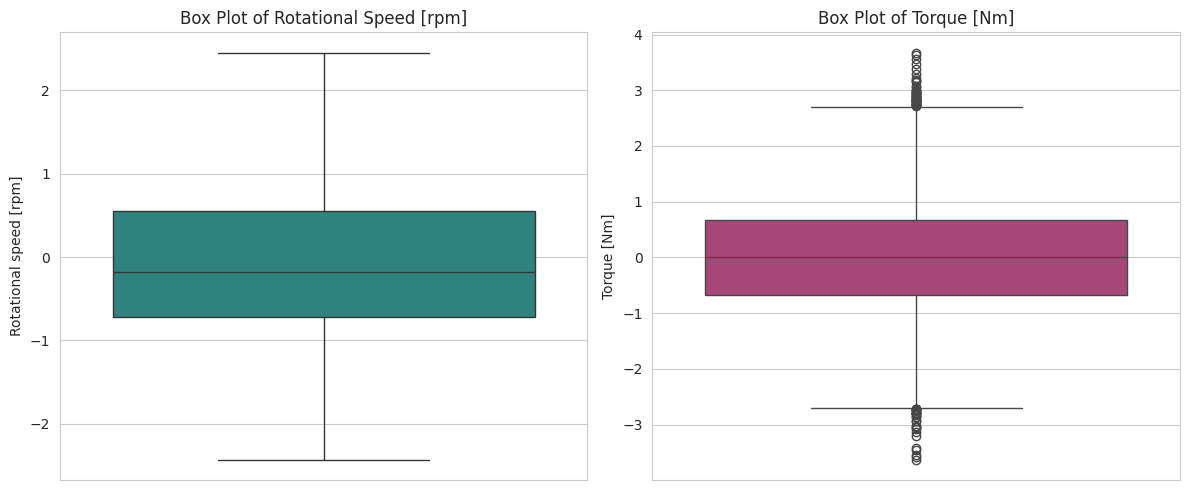

In [51]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_train['Rotational speed [rpm]'], palette='viridis')
plt.title('Box Plot of Rotational Speed [rpm]')
plt.ylabel('Rotational speed [rpm]')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_train['Torque [Nm]'], palette='magma')
plt.title('Box Plot of Torque [Nm]')
plt.ylabel('Torque [Nm]')

plt.tight_layout()
plt.show()

Box Plots (Rotational Speed & Torque: Plot ini menunjukkan distribusi dan keberadaan outlier untuk kecepatan putaran dan torsi. Anda bisa melihat sebaran data dan titik-titik yang jauh dari mayoritas data.

#### 2. Analisis Univariat: Histograms untuk Distribusi Suhu dan Keausan Alat

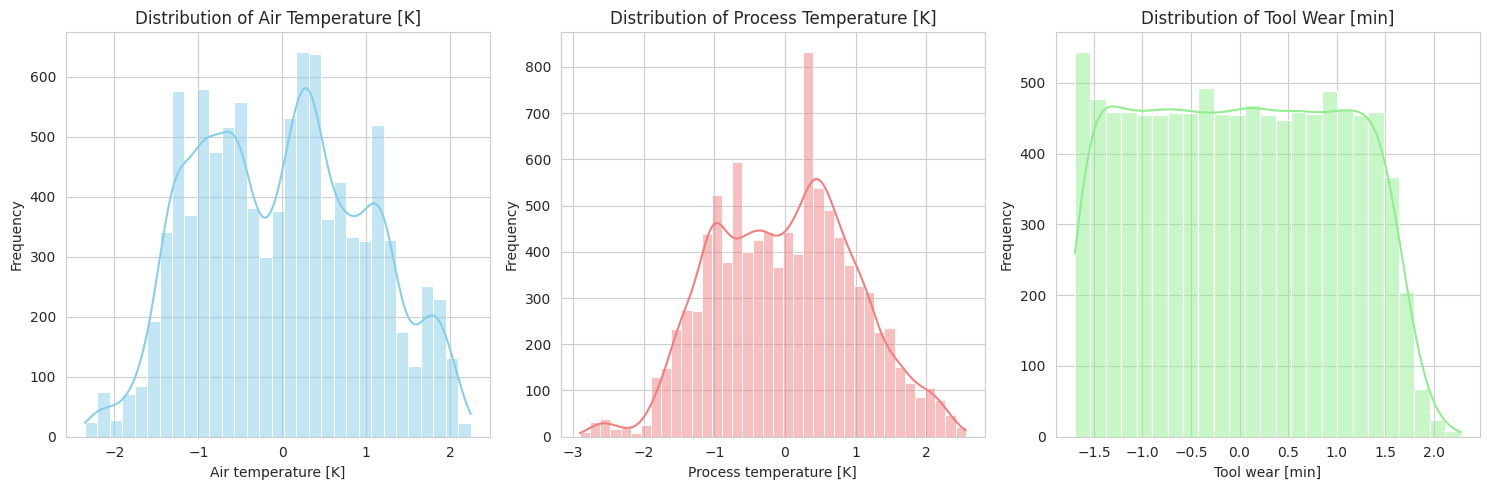

In [50]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_train['Air temperature [K]'], kde=True, color='skyblue')
plt.title('Distribution of Air Temperature [K]')
plt.xlabel('Air temperature [K]')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df_train['Process temperature [K]'], kde=True, color='lightcoral')
plt.title('Distribution of Process Temperature [K]')
plt.xlabel('Process temperature [K]')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df_train['Tool wear [min]'], kde=True, color='lightgreen')
plt.title('Distribution of Tool Wear [min]')
plt.xlabel('Tool wear [min]')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Histograms (Air Temp, Process Temp, Tool Wear): Histogram-histogram ini menggambarkan distribusi suhu udara, suhu proses, dan keausan alat. Anda dapat melihat apakah distribusinya cenderung normal, miring ke satu sisi (skewed), atau memiliki pola tertentu.

#### 3. Analisis Multivariat: Heatmap Korelasi Antar Suhu

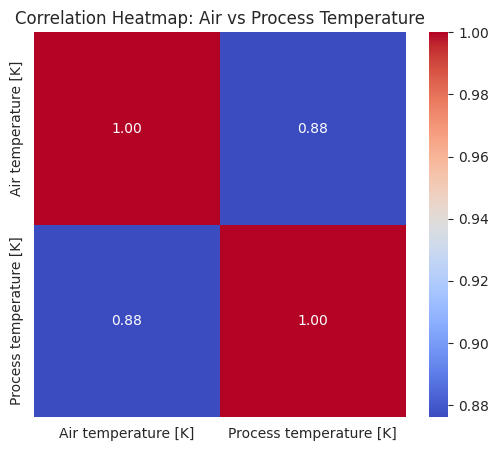

In [49]:
temp_cols = ['Air temperature [K]', 'Process temperature [K]']
correlation_matrix = df_train[temp_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Air vs Process Temperature')
plt.show()

if correlation_matrix.loc['Air temperature [K]', 'Process temperature [K]'] > 0.9:
    print("Korelasi antara Suhu Udara dan Suhu Proses sangat tinggi (> 0.9), mengindikasikan potensi multikolinearitas.")

Heatmap Korelasi Suhu: Heatmap menunjukkan korelasi yang tinggi (0.88) antara suhu udara dan suhu proses. Seperti yang telah Anda sebutkan, korelasi di atas 0.9 dapat mengindikasikan multikolinearitas.

#### 4. Analisis Multivariat: Scatter Plot Torque vs RPM

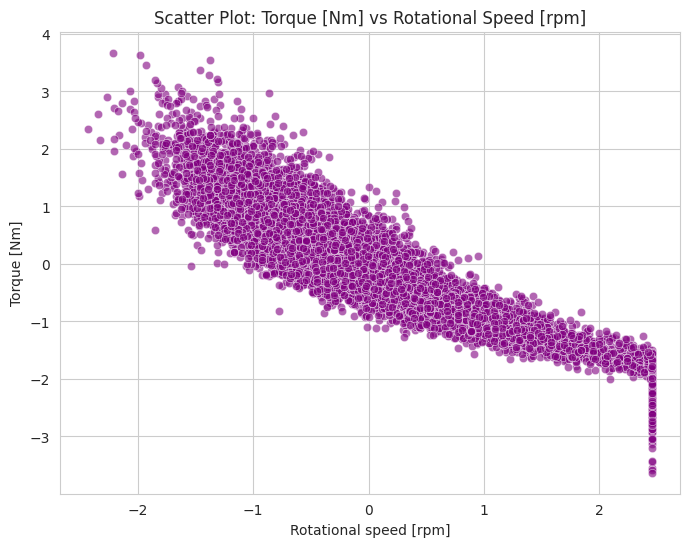

In [48]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_train['Rotational speed [rpm]'], y=df_train['Torque [Nm]'], alpha=0.6, color='purple')
plt.title('Scatter Plot: Torque [Nm] vs Rotational Speed [rpm]')
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.show()

Scatter Plot (Torque vs RPM): Plot ini memvisualisasikan hubungan antara torsi dan kecepatan putaran. Pola yang terlihat dapat memberikan wawasan tentang perilaku mesin.

#### 5. Analisis Distribusi Target: Bar Plot Rasio Machine Failure

/tmp/ipykernel_4302/181681727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='plasma')


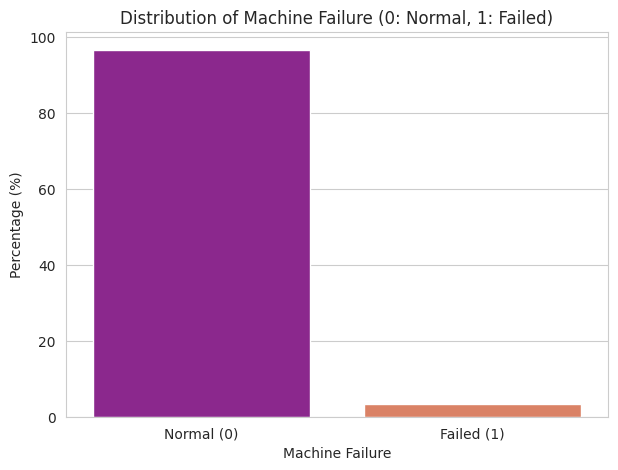

Distribusi Machine Failure:
Machine failure
0    96.603887
1     3.396113
Name: proportion, dtype: float64


In [47]:
failure_counts = df['Machine failure'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='plasma')
plt.title('Distribution of Machine Failure (0: Normal, 1: Failed)')
plt.xlabel('Machine Failure')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Failed (1)'])
plt.show()

print("Distribusi Machine Failure:")
print(failure_counts)

Bar Plot Distribusi Machine Failure: Plot ini menunjukkan distribusi kelas target. Terlihat bahwa sekitar 96.6% data adalah 'Normal' (0) dan hanya sekitar 3.4% adalah 'Failed' (1). Ini mengindikasikan masalah ketidakseimbangan kelas (class imbalance) yang mungkin perlu ditangani dalam tahap pemodelan.

### Data Transformation

#### 1. Penanganan Outlier menggunakan Metode IQR (Interquartile Range)

In [46]:
import numpy as np

# Outlier Handling for 'Rotational speed [rpm]'
Q1 = df_train['Rotational speed [rpm]'].quantile(0.25)
Q3 = df_train['Rotational speed [rpm]'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap the outliers using .loc to avoid SettingWithCopyWarning
df_train.loc[:, 'Rotational speed [rpm]'] = np.where(
    df_train['Rotational speed [rpm]'] < lower_bound, lower_bound,
    np.where(df_train['Rotational speed [rpm]'] > upper_bound, upper_bound,
             df_train['Rotational speed [rpm]']
    )
)

print(f"Outliers in 'Rotational speed [rpm]' have been capped using IQR method.")

# Display summary statistics after capping
print(df_train['Rotational speed [rpm]'].describe())

Outliers in 'Rotational speed [rpm]' have been capped using IQR method.
count    9.982000e+03
mean     1.637195e-17
std      1.000050e+00
min     -2.433513e+00
25%     -7.203198e-01
50%     -1.828474e-01
75%      5.494588e-01
max      2.454127e+00
Name: Rotational speed [rpm], dtype: float64


#### 2. Feature Scaling menggunakan StandardScaler

In [45]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features for scaling (excluding binary 'Type' columns)
numerical_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]', # Outliers have been handled
    'Torque [Nm]',
    'Tool wear [min]'
]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical features using .loc to avoid SettingWithCopyWarning
df_train.loc[:, numerical_features] = scaler.fit_transform(df_train[numerical_features])

print("Numerical features have been scaled using StandardScaler.")

# Display the first few rows of the transformed DataFrame
print('\nDataFrame after scaling:')
print(df_train.head())

Numerical features have been scaled using StandardScaler.

DataFrame after scaling:
   Type_L  Type_M  Type_H  Air temperature [K]  Process temperature [K]  \
0   False    True   False            -0.951585                -0.946639   
1    True   False   False            -0.901595                -0.879224   
2    True   False   False            -0.951585                -1.014053   
3    True   False   False            -0.901595                -0.946639   
4    True   False   False            -0.901595                -0.879224   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
0                0.139636     0.282902        -1.695845  
1               -0.821096     0.634089        -1.648708  
2               -0.216439     0.945140        -1.617283  
3               -0.653136    -0.048216        -1.585858  
4               -0.821096     0.001953        -1.554432  


### Penanganan Ketidakseimbangan Kelas: SMOTE

In [69]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Convert boolean columns in X to int for SMOTE compatibility
X_smote = X.copy()
for col in X_smote.select_dtypes(include='bool').columns:
    X_smote[col] = X_smote[col].astype(int)

print(f"Original class distribution: {Counter(y)}")

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_smote, y)

print(f"Resampled class distribution: {Counter(y_res)}")

# Update X and y to the resampled versions
X = X_res
y = y_res

print("SMOTE applied successfully. X and y have been updated with resampled data.")

Original class distribution: Counter({0: 9643, 1: 339})
Resampled class distribution: Counter({0: 9643, 1: 9643})
SMOTE applied successfully. X and y have been updated with resampled data.


### Final Validation After Data Transformation and SMOTE

In [70]:
print("\n--- X (Features) after SMOTE ---")
print("Shape of X:", X.shape)
print("First 5 rows of X:")
print(X.head())
print("\nInfo of X:")
X.info()

print("\n--- y (Target) after SMOTE ---")
print("Shape of y:", y.shape)
print("First 5 rows of y:")
print(y.head())
print("\nValue counts of y:")
print(y.value_counts())


--- X (Features) after SMOTE ---
Shape of X: (19286, 8)
First 5 rows of X:
   Type_L  Type_M  Type_H  Air temperature [K]  Process temperature [K]  \
0       0       1       0                298.1                    308.6   
1       1       0       0                298.2                    308.7   
2       1       0       0                298.1                    308.5   
3       1       0       0                298.2                    308.6   
4       1       0       0                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
0                  1551.0         42.8                0  
1                  1408.0         46.3                3  
2                  1498.0         49.4                5  
3                  1433.0         39.5                7  
4                  1408.0         40.0                9  

Info of X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19286 entries, 0 to 19285
Data columns (total 8 columns):
 #   

Data Fitur (X): Sekarang memiliki 19.286 baris dan 8 kolom. Ini adalah peningkatan dari jumlah baris awal karena SMOTE telah menghasilkan sampel baru untuk menyeimbangkan kelas. Semua kolom memiliki tipe data yang sesuai (integer untuk One-Hot Encoded 'Type', float untuk fitur numerik lainnya), dan tidak ada nilai yang hilang.
Data Target (y): Sekarang memiliki 19.286 baris. Yang terpenting, distribusi kelas sudah seimbang sempurna, dengan masing-masing 9.643 sampel untuk 'Machine failure' 0 dan 1.

### Reduksi Dimensi (UMAP) setelah SMOTE

#### Menerapkan UMAP untuk Reduksi Dimensi pada data yang sudah di-SMOTE

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Data has been transformed using UMAP after SMOTE.
Shape of X_umap: (19286, 2)


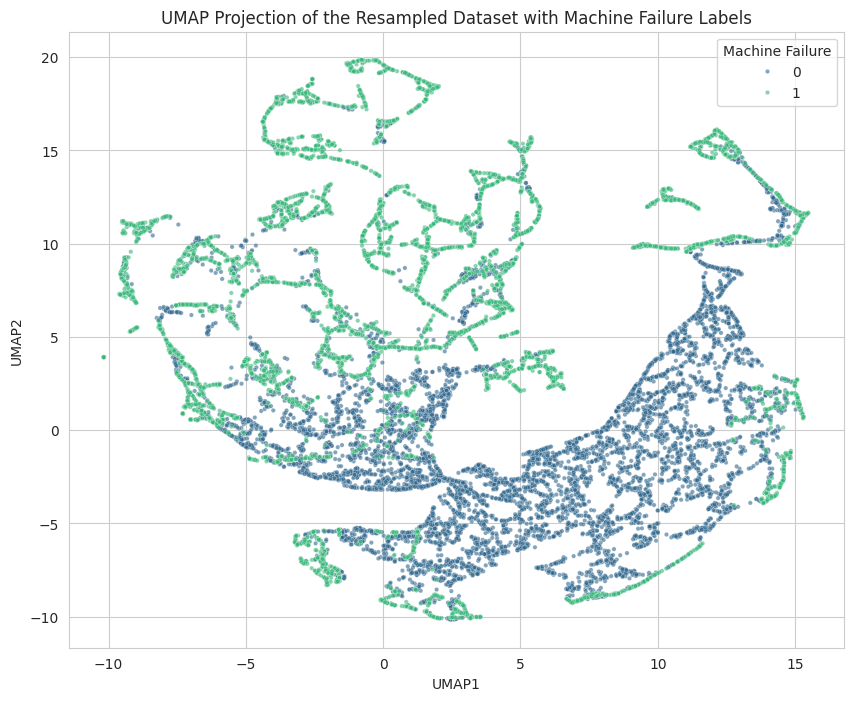

In [71]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize UMAP
umap_reducer = umap.UMAP(random_state=42)

# Fit and transform the data (X is already resampled by SMOTE)
X_umap = umap_reducer.fit_transform(X)

print("Data has been transformed using UMAP after SMOTE.")
print("Shape of X_umap:", X_umap.shape)

# Create a DataFrame for the UMAP results for easier plotting
df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Machine failure'] = y.values # Add the target variable (y is already resampled)

# Plot the UMAP results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Machine failure',
    palette='viridis',
    data=df_umap,
    s=10, # Marker size
    alpha=0.6 # Transparency
)
plt.title('UMAP Projection of the Resampled Dataset with Machine Failure Labels')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='Machine Failure')
plt.show()

UMAP: Data Anda sekarang telah direduksi menjadi 2 dimensi (X_umap memiliki shape (19286, 2)), memungkinkan visualisasi yang efektif. Plot UMAP yang ditampilkan menunjukkan bagaimana titik-titik data terdistribusi dalam ruang 2D ini, dengan warna yang membedakan antara 'Machine failure' 0 dan 1. Kita bisa mengamati apakah ada pemisahan yang jelas antara kedua kelas setelah SMOTE.

### Klastering (GMM) setelah SMOTE

#### Menerapkan Gaussian Mixture Model (GMM) pada data UMAP yang sudah di-SMOTE

#### Visualisasi Klaster GMM pada UMAP setelah SMOTE

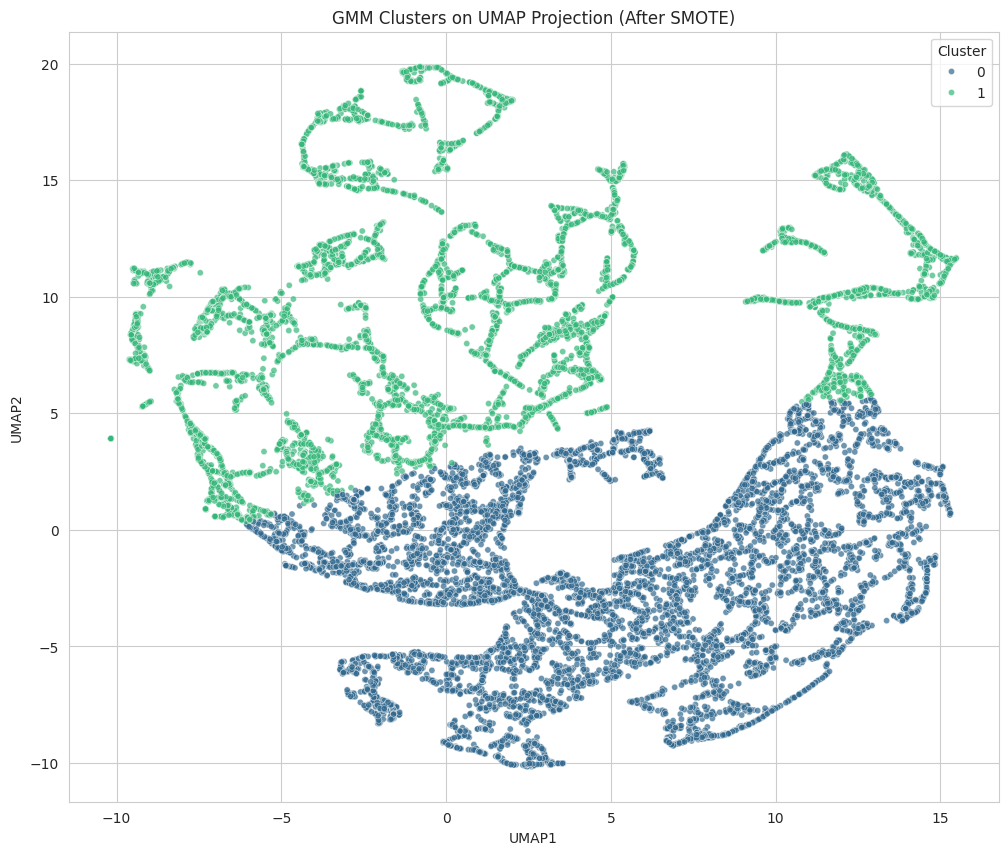

In [75]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='GMM_Cluster',
    palette='viridis',
    data=df_umap,
    s=20, # Marker size
    alpha=0.7
)
plt.title('GMM Clusters on UMAP Projection (After SMOTE)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='Cluster')
plt.show()

In [74]:
from sklearn.mixture import GaussianMixture
import numpy as np

# Initialize GMM with a chosen number of components (e.g., 3, based on prior knowledge or experimentation)
gmm = GaussianMixture(n_components=2, random_state=42)

# Fit GMM to the UMAP-reduced data (X_umap from resampled X)
gmm_labels = gmm.fit_predict(X_umap)

# Add GMM cluster labels to df_umap
df_umap['GMM_Cluster'] = gmm_labels

print("GMM clustering completed on UMAP data after SMOTE.")
print("Number of clusters found:", len(np.unique(gmm_labels)))
print("First 5 rows of df_umap with GMM labels:")
print(df_umap.head())

GMM clustering completed on UMAP data after SMOTE.
Number of clusters found: 2
First 5 rows of df_umap with GMM labels:
      UMAP1     UMAP2  Machine failure  GMM_Cluster
0  5.904219 -0.972685                0            0
1 -4.933459 -0.930975                0            0
2  1.765020 -2.892354                0            0
3 -2.841120 -2.284540                0            0
4 -4.781168 -0.947538                0            0


### Klastering (HDBSCAN) pada data UMAP yang sudah di-SMOTE

In [91]:
import hdbscan

# Initialize HDBSCAN
# min_cluster_size: The minimum size of clusters HDBSCAN should detect (e.g., 5-10% of data points for smaller clusters)
# min_samples: The number of samples in a neighbourhood for a point to be considered as a core point (similar to DBSCAN)
# cluster_selection_epsilon: A distance threshold that can be used to merge clusters (smaller values mean more clusters)
hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=100, cluster_selection_epsilon=0.05, prediction_data=True)

# Fit HDBSCAN to the UMAP-reduced data
hdbscan_labels = hdbscan_clusterer.fit_predict(X_umap)

# Add HDBSCAN cluster labels to df_umap
df_umap['HDBSCAN_Cluster'] = hdbscan_labels

print("HDBSCAN clustering completed on UMAP data after SMOTE.")
print(f"Number of clusters found by HDBSCAN (excluding noise -1): {len(np.unique(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)}")
print("Number of noise points (-1):", list(hdbscan_labels).count(-1))
print("First 5 rows of df_umap with HDBSCAN labels:")
print(df_umap.head())

HDBSCAN clustering completed on UMAP data after SMOTE.
Number of clusters found by HDBSCAN (excluding noise -1): 2
Number of noise points (-1): 20
First 5 rows of df_umap with HDBSCAN labels:
      UMAP1     UMAP2  Machine failure  GMM_Cluster  HDBSCAN_Cluster
0  5.904219 -0.972685                0            0                1
1 -4.933459 -0.930975                0            0                1
2  1.765020 -2.892354                0            0                1
3 -2.841120 -2.284540                0            0                1
4 -4.781168 -0.947538                0            0                1


#### Visualisasi Klaster HDBSCAN pada UMAP setelah SMOTE

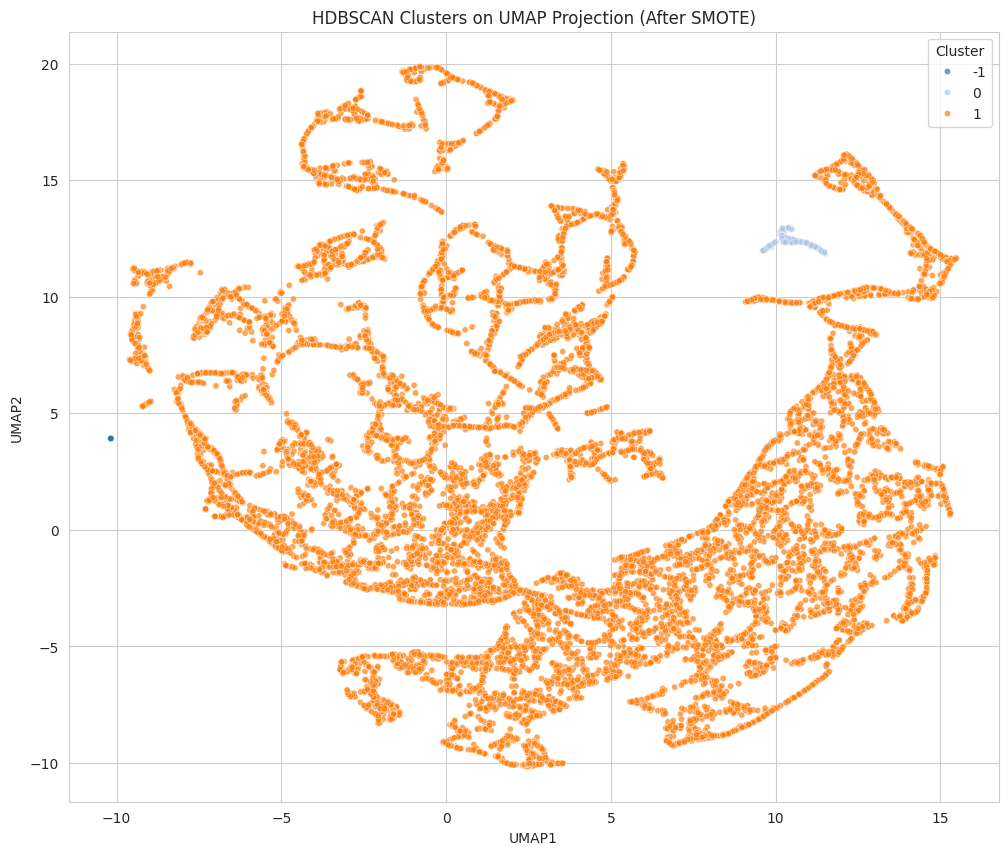

In [92]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='HDBSCAN_Cluster',
    palette='tab20',
    data=df_umap,
    s=20, # Marker size
    alpha=0.7
)
plt.title('HDBSCAN Clusters on UMAP Projection (After SMOTE)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='Cluster')
plt.show()

### Perbandingan Klastering (GMM vs HDBSCAN) dan Metrik Evaluasi

In [81]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# Filter out noise points for HDBSCAN for some metrics if needed, or handle them
# For ARI/NMI, noise points are typically considered a separate 'cluster'.

# 1. Adjusted Rand Index (ARI) - Measures similarity between two clusterings, ignoring permutations.
#    Compares GMM clusters and HDBSCAN clusters to the 'Machine failure' ground truth.
ari_gmm = adjusted_rand_score(df_umap['Machine failure'], df_umap['GMM_Cluster'])
ari_hdbscan = adjusted_rand_score(df_umap['Machine failure'], df_umap['HDBSCAN_Cluster'])

# 2. Normalized Mutual Information (NMI) - Measures the mutual dependence between two clusterings.
nmi_gmm = normalized_mutual_info_score(df_umap['Machine failure'], df_umap['GMM_Cluster'])
nmi_hdbscan = normalized_mutual_info_score(df_umap['Machine failure'], df_umap['HDBSCAN_Cluster'])

# 3. Silhouette Score - Measures how similar an object is to its own cluster (cohesion)
#    compared to other clusters (separation). Higher is better. Range from -1 to 1.
#    Cannot be calculated if there's only one cluster or all points are noise.

# Handle cases where HDBSCAN might produce only noise or one cluster for silhouette_score
try:
    # Exclude noise points (-1) from silhouette score calculation for HDBSCAN for a clearer score
    # on actual clusters. Alternatively, could treat -1 as its own cluster.
    # Let's try treating -1 as its own cluster for this example
    if len(np.unique(df_umap['HDBSCAN_Cluster'])) > 1:
        silhouette_hdbscan = silhouette_score(X_umap, df_umap['HDBSCAN_Cluster'])
    else:
        silhouette_hdbscan = np.nan # Not enough clusters for silhouette
except ValueError:
    silhouette_hdbscan = np.nan

try:
    if len(np.unique(df_umap['GMM_Cluster'])) > 1:
        silhouette_gmm = silhouette_score(X_umap, df_umap['GMM_Cluster'])
    else:
        silhouette_gmm = np.nan
except ValueError:
    silhouette_gmm = np.nan

print("\n--- Klastering GMM ---")
print(f"Adjusted Rand Index (vs Machine failure): {ari_gmm:.4f}")
print(f"Normalized Mutual Information (vs Machine failure): {nmi_gmm:.4f}")
print(f"Silhouette Score: {silhouette_gmm:.4f}")

print("\n--- Klastering HDBSCAN ---")
print(f"Adjusted Rand Index (vs Machine failure): {ari_hdbscan:.4f}")
print(f"Normalized Mutual Information (vs Machine failure): {nmi_hdbscan:.4f}")
print(f"Silhouette Score: {silhouette_hdbscan:.4f}")

print("\nKesimpulan awal berdasarkan metrik evaluasi:")
if ari_gmm > ari_hdbscan:
    print("GMM menunjukkan kesamaan klaster yang lebih tinggi dengan label 'Machine failure' berdasarkan ARI.")
else:
    print("HDBSCAN menunjukkan kesamaan klaster yang lebih tinggi dengan label 'Machine failure' berdasarkan ARI.")

if nmi_gmm > nmi_hdbscan:
    print("GMM menunjukkan lebih banyak informasi bersama dengan label 'Machine failure' berdasarkan NMI.")
else:
    print("HDBSCAN menunjukkan lebih banyak informasi bersama dengan label 'Machine failure' berdasarkan NMI.")

if silhouette_gmm > silhouette_hdbscan:
    print("GMM menghasilkan klaster yang lebih rapat dan terpisah berdasarkan Silhouette Score.")
elif not np.isnan(silhouette_hdbscan):
    print("HDBSCAN menghasilkan klaster yang lebih rapat dan terpisah berdasarkan Silhouette Score.")
else:
    print("Tidak dapat membandingkan Silhouette Score karena HDBSCAN tidak memiliki cukup klaster.")


--- Klastering GMM ---
Adjusted Rand Index (vs Machine failure): 0.3412
Normalized Mutual Information (vs Machine failure): 0.2625
Silhouette Score: 0.3851

--- Klastering HDBSCAN ---
Adjusted Rand Index (vs Machine failure): 0.0005
Normalized Mutual Information (vs Machine failure): 0.0184
Silhouette Score: -0.1102

Kesimpulan awal berdasarkan metrik evaluasi:
GMM menunjukkan kesamaan klaster yang lebih tinggi dengan label 'Machine failure' berdasarkan ARI.
GMM menunjukkan lebih banyak informasi bersama dengan label 'Machine failure' berdasarkan NMI.
GMM menghasilkan klaster yang lebih rapat dan terpisah berdasarkan Silhouette Score.


### Optimasi Parameter HDBSCAN

In [88]:
from sklearn.metrics import silhouette_score
import hdbscan
import numpy as np

# Define parameter ranges to search
min_cluster_sizes = [5, 10, 15, 20, 30, 50]
min_samples_list = [5, 10, 20, 50]

best_score = -1
best_params = {}
results = []

print("Mulai pencarian parameter untuk HDBSCAN...")

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_list:
        # Ensure min_samples is not greater than min_cluster_size
        if min_samples > min_cluster_size:
            continue

        try:
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                metric='euclidean', # Default, or try 'manhattan', etc.
                prediction_data=True
            )
            labels = clusterer.fit_predict(X_umap)

            # Calculate Silhouette Score, excluding noise points (-1)
            # Only calculate if more than 1 cluster and not all points are noise
            unique_labels = np.unique(labels)
            if len(unique_labels) > 1 and not (len(unique_labels) == 1 and unique_labels[0] == -1):
                # Filter out noise points for silhouette calculation if desired
                # Here, we include noise as a separate cluster to be consistent with overall evaluation
                score = silhouette_score(X_umap, labels)
            else:
                score = -1 # Assign a low score if not enough clusters or only noise

            results.append({
                'min_cluster_size': min_cluster_size,
                'min_samples': min_samples,
                'silhouette_score': score,
                'num_clusters': len(unique_labels) - (1 if -1 in unique_labels else 0),
                'num_noise_points': list(labels).count(-1)
            })

            if score > best_score:
                best_score = score
                best_params = {'min_cluster_size': min_cluster_size, 'min_samples': min_samples}

        except Exception as e:
            print(f"Error with min_cluster_size={min_cluster_size}, min_samples={min_samples}: {e}")
            results.append({
                'min_cluster_size': min_cluster_size,
                'min_samples': min_samples,
                'silhouette_score': -1, # Indicate failure or very poor score
                'num_clusters': 0,
                'num_noise_points': len(X_umap)
            })

print("Pencarian parameter selesai.")
print(f"Parameter terbaik ditemukan: {best_params} dengan Silhouette Score: {best_score:.4f}")

# Display results as a DataFrame for better readability
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='silhouette_score', ascending=False)
print("\nTop 10 Hasil Pencarian Parameter:")
display(results_df.head(10))

Mulai pencarian parameter untuk HDBSCAN...
Pencarian parameter selesai.
Parameter terbaik ditemukan: {'min_cluster_size': 10, 'min_samples': 5} dengan Silhouette Score: 0.3278

Top 10 Hasil Pencarian Parameter:


,min_cluster_size,min_samples,silhouette_score,num_clusters,num_noise_points
1,10,5,0.327796,666,3520
3,15,5,0.326659,500,3159
0,5,5,0.311148,964,3973
5,20,5,0.300417,375,3281
4,15,10,0.270597,439,4261
8,30,5,0.264404,240,3026
6,20,10,0.258869,326,3944
2,10,10,0.255601,545,4735
11,50,5,0.234324,130,2827
9,30,10,0.232302,204,3472


Setelah menjalankan pencarian parameter, kita dapat menganalisis hasil untuk menemukan kombinasi `min_cluster_size` dan `min_samples` yang memberikan Silhouette Score tertinggi. Silhouette Score yang lebih tinggi menunjukkan klaster yang lebih padat dan terpisah.

Perhatikan juga jumlah klaster yang dihasilkan dan jumlah titik *noise* untuk setiap kombinasi, karena ini juga merupakan pertimbangan penting dalam memilih model klastering yang paling sesuai dengan tujuan analisis Anda.